# Game W/L Estimator (NBA)
Modelo de clasificación para estimar la probabilidad de victoria entre dos equipos (home vs away) usando datos de *team gamelogs*.
- Target: `WL_NUM` (1=Win, 0=Loss).
- Modelos: Logistic Regression y RandomForestClassifier.
- Métricas: Accuracy, F1, ROC-AUC.
- Visualizaciones: Curva ROC, matriz de confusión, importancia de variables.
- Inferencia “bonita”: parámetro de equipos HOME/AWAY + ventana de últimos N partidos → probabilidad de victoria.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
import warnings; warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.grid"] = True

## Parámetros de usuario
Sustituye aquí los equipos del partido y el tamaño de la ventana para medias recientes.

In [44]:
# === PARÁMETROS DE USUARIO ===
# Nombre de los equipos (exactamente como aparecen en TEAM_NAME del parquet)
HOME_TEAM = "Oklahoma City Thunder"
AWAY_TEAM = "Indiana Pacers"

# Ventana de partidos recientes usada para calcular medias (forma del equipo)
LAST_N = 20   # puedes probar 5, 10, 15, 20...

# Temporada y ruta al parquet de gamelogs
SEASON = "2024-25"
PARQUET_PATH = f"/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/{SEASON}/teamgamelogs_by_game.parquet"

# Validaciones básicas (te avisan si algo está mal)
import os

if not os.path.exists(PARQUET_PATH):
    raise FileNotFoundError(f"❌ No se encontró el parquet en {PARQUET_PATH}")

if not isinstance(LAST_N, int) or LAST_N <= 0:
    raise ValueError("❌ LAST_N debe ser un entero positivo (ej. 5, 10, 20)")

print(f"🏀 Temporada: {SEASON}")
print(f"🏠 HOME_TEAM: {HOME_TEAM}")
print(f"🛫 AWAY_TEAM: {AWAY_TEAM}")
print(f"📊 Ventana (LAST_N): {LAST_N} partidos")
print(f"📁 Archivo de datos: {PARQUET_PATH}")

🏀 Temporada: 2024-25
🏠 HOME_TEAM: Oklahoma City Thunder
🛫 AWAY_TEAM: Indiana Pacers
📊 Ventana (LAST_N): 20 partidos
📁 Archivo de datos: /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/teamgamelogs_by_game.parquet


## Carga y preprocesado
- Carga parquet de team gamelogs (dos filas por partido).
- Genera `WL_NUM` si no existe.
- Selecciona solo columnas numéricas útiles (excluye IDs/strings).

In [45]:
df = pd.read_parquet(PARQUET_PATH)

# --- WL → numérica (robusto ante nulos o valores raros)
if "WL_NUM" not in df.columns:
    wl_col = df.get("WL")
    df["WL_NUM"] = (
        wl_col.astype(str)
             .str.strip()
             .str.upper()
             .map({"W": 1, "L": 0})
             .astype("Int64")
    )

# --- Excluir identificadores y texto (no predictivo directo)
exclude_cols = {
    "GAME_ID","GAME_DATE","MATCHUP","TEAM_ID","TEAM_NAME","TEAM_ABBREVIATION",
    "SEASON_YEAR","SEASON_ID","GAMECODE","TEAM_CITY","TEAM_NICKNAME","WL","WL_NUM"
}

# --- Columnas con FUGA (post-game) a eliminar - MÁS AGRESIVO ---
hard_leaks = {
    # Resultado o derivados directos
    "PTS","PLUS_MINUS",
    # Ratings y rankings (usan info de toda la temporada)
    "OFF_RATING","DEF_RATING","NET_RATING","E_OFF_RATING","E_DEF_RATING","E_NET_RATING",
    "GP_RANK","W_RANK","L_RANK","W_PCT_RANK","MIN_RANK","FGM_RANK","FGA_RANK","FG_PCT_RANK",
    "FG3M_RANK","FG3A_RANK","FG3_PCT_RANK","FTM_RANK","FTA_RANK","FT_PCT_RANK","OREB_RANK",
    "DREB_RANK","REB_RANK","AST_RANK","TOV_RANK","STL_RANK","BLK_RANK","BLKA_RANK","PF_RANK",
    "PFD_RANK","PTS_RANK","PLUS_MINUS_RANK",
    # Estadísticas del oponente (FUGA GRAVE - se conocen después del partido)
    "OPP_EFG_PCT", "OPP_FG_PCT", "OPP_FG3_PCT", "OPP_FT_PCT", "OPP_TS_PCT",
    "OPP_OREB", "OPP_DREB", "OPP_REB", "OPP_AST", "OPP_TOV", "OPP_STL", "OPP_BLK",
    "OPP_PF", "OPP_PFD", "OPP_FGM", "OPP_FGA", "OPP_FG3M", "OPP_FG3A", "OPP_FTM", "OPP_FTA",
    # Otros
    "AVAILABLE_FLAG","season","game_id","endpoint"
}

# tokens genéricos de fuga/resumen del resultado del propio partido
leak_name_tokens = ("PLUS", "RATING", "MARGIN", "DIFF", "NET", "RANK", "POSS", "PACE", "OPP_")

def is_leak(col: str) -> bool:
    if col in hard_leaks:
        return True
    c = col.upper()
    # cualquier *_RANK
    if c.endswith("_RANK"):
        return True
    # patrones genéricos
    return any(tok in c for tok in leak_name_tokens)

# --- Selección de numéricas válidas (sin IDs ni fugas)
candidate_numeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
num_cols = [
    c for c in candidate_numeric
    if c not in exclude_cols and not is_leak(c)
]

print(f"Características numéricas iniciales: {len(candidate_numeric)}")
print(f"Características después de eliminar fugas: {len(num_cols)}")
print(f"Características eliminadas: {len(candidate_numeric) - len(num_cols)}")

# --- Ensamblado y limpieza mínima
use_cols = ["GAME_ID","GAME_DATE","TEAM_NAME","WL_NUM"] + num_cols
df_clean = df.loc[:, [c for c in use_cols if c in df.columns]].copy()

# Asegura fecha válida y target presente
df_clean["GAME_DATE"] = pd.to_datetime(df_clean["GAME_DATE"], errors="coerce")
df_clean = df_clean.dropna(subset=["WL_NUM","GAME_DATE"])

# Por seguridad: elimina duplicados exactos de (GAME_ID, TEAM_NAME)
df_clean = df_clean.sort_values(["GAME_DATE","GAME_ID","TEAM_NAME"])
df_clean = df_clean.drop_duplicates(subset=["GAME_ID","TEAM_NAME"], keep="last")

# Convierte infinitos a NaN (a veces hay divisiones % raras)
df_clean[num_cols] = df_clean[num_cols].replace([np.inf, -np.inf], np.nan)

# Rellena NaNs numéricos con la mediana *global* (simple y estable)
medians = df_clean[num_cols].median()
df_clean[num_cols] = df_clean[num_cols].fillna(medians)

print(f"Total filas válidas: {len(df_clean):,} | #features: {len(num_cols)}")

# Diagnóstico rápido: top 10 columnas con mayor correlación (absoluta) con WL_NUM
try:
    corr_abs = df_clean[num_cols + ["WL_NUM"]].corr(numeric_only=True)["WL_NUM"].abs().sort_values(ascending=False)
    print("Top-10 |corr(feature, WL_NUM)|:")
    for feature, corr_value in corr_abs.drop("WL_NUM").head(10).items():
        print(f"  {feature}: {corr_value:.3f}")
except Exception as e:
    print(f"Error en correlación: {e}")

Características numéricas iniciales: 118
Características después de eliminar fugas: 70
Características eliminadas: 48
Total filas válidas: 2,639 | #features: 70
Top-10 |corr(feature, WL_NUM)|:
  FG_PCT: 0.425
  FGM: 0.376
  FG3_PCT: 0.344
  DREB: 0.330
  AST: 0.294
  REB: 0.280
  EFG_PCT: 0.273
  FG3M: 0.273
  TS_PCT: 0.273
  PTS_OFF_TOV: 0.244


## División train/test y modelos
- Train/test = 80/20 con estratificación.
- Baseline (Dummy).
- Logistic Regression (con StandardScaler).
- RandomForestClassifier.
- Métricas: Accuracy, F1, ROC-AUC.

In [46]:
# --- 1) Filtro de columnas con fuga REVISADO ---
base_exclude = {
    "GAME_ID","GAME_DATE","MATCHUP","TEAM_ID","TEAM_NAME","TEAM_ABBREVIATION",
    "SEASON_YEAR","SEASON_ID","GAMECODE","TEAM_CITY","TEAM_NICKNAME","WL","WL_NUM",
    "AVAILABLE_FLAG","season","game_id","endpoint"
}

hard_leaks = {
    # Resultado o derivados directos
    "PTS","PLUS_MINUS",
    # Ratings
    "OFF_RATING","DEF_RATING","NET_RATING","E_OFF_RATING","E_DEF_RATING","E_NET_RATING",
    # Rankings
    "GP_RANK","W_RANK","L_RANK","W_PCT_RANK","MIN_RANK","FGM_RANK","FGA_RANK","FG_PCT_RANK",
    "FG3M_RANK","FG3A_RANK","FG3_PCT_RANK","FTM_RANK","FTA_RANK","FT_PCT_RANK","OREB_RANK",
    "DREB_RANK","REB_RANK","AST_RANK","TOV_RANK","STL_RANK","BLK_RANK","BLKA_RANK","PF_RANK",
    "PFD_RANK","PTS_RANK","PLUS_MINUS_RANK",
    # Estadísticas del oponente (IMPORTANTE: ELIMINAR ESTAS)
    "OPP_EFG_PCT", "OPP_FG_PCT", "OPP_FG3_PCT", "OPP_FT_PCT", "OPP_TS_PCT",
    "OPP_OREB", "OPP_DREB", "OPP_REB", "OPP_AST", "OPP_TOV", "OPP_STL", "OPP_BLK",
    "OPP_PF", "OPP_PFD", "OPP_FGM", "OPP_FGA", "OPP_FG3M", "OPP_FG3A", "OPP_FTM", "OPP_FTA"
}

leak_tokens = ("PLUS", "RATING", "MARGIN", "DIFF", "NET", "PCT_RANK", "RANK", "POSS", "PACE", "OPP_")

def is_leak(col: str) -> bool:
    c = col.upper()
    if col in base_exclude or col in hard_leaks:
        return True
    # cualquier *_RANK
    if c.endswith("_RANK") or c.endswith("_PCT_RANK"):
        return True
    # patrones genéricos
    return any(tok in c for tok in leak_tokens)

# columnas numéricas candidatas
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
num_cols = [c for c in numeric_cols if not is_leak(c)]

print(f"Características finales para modelo: {len(num_cols)}")

# --- 2) Split temporal sin mezclar GAME_ID ---
df_clean = df[["GAME_ID","GAME_DATE","TEAM_NAME","WL_NUM"] + num_cols].copy()
df_clean["GAME_DATE"] = pd.to_datetime(df_clean["GAME_DATE"], errors="coerce")
df_clean = df_clean.dropna(subset=["WL_NUM","GAME_DATE"])
df_clean = df_clean.sort_values("GAME_DATE")

unique_dates = df_clean["GAME_DATE"].unique()
if len(unique_dates) < 3:
    cut_idx = int(0.8 * len(df_clean))
    cut_date = df_clean.iloc[cut_idx]["GAME_DATE"]
else:
    cut_idx = int(0.8 * len(unique_dates))
    cut_idx = min(max(cut_idx, 1), len(unique_dates)-1)
    cut_date = unique_dates[cut_idx]

train_ids = df_clean.loc[df_clean["GAME_DATE"] <= cut_date, "GAME_ID"].unique()
test_ids  = df_clean.loc[df_clean["GAME_DATE"] >  cut_date, "GAME_ID"].unique()

train_mask = df_clean["GAME_ID"].isin(train_ids)
test_mask  = df_clean["GAME_ID"].isin(test_ids)

X_train = df_clean.loc[train_mask, num_cols].copy()
y_train = df_clean.loc[train_mask, "WL_NUM"].astype(int).copy()
X_test  = df_clean.loc[test_mask,  num_cols].copy()
y_test  = df_clean.loc[test_mask,  "WL_NUM"].astype(int).copy()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# --- 3) Imputación solo con estadística de train ---
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test  = X_test.fillna(medians)

# elimina cuasi-constantes (varianza muy baja)
vt = VarianceThreshold(threshold=1e-10)
X_train = pd.DataFrame(vt.fit_transform(X_train), columns=np.array(num_cols)[vt.get_support()], index=X_train.index)
X_test  = pd.DataFrame(vt.transform(X_test),    columns=X_train.columns, index=X_test.index)

# corta fugas residuales por correlación extrema con el target en TRAIN
corr_with_y = X_train.assign(WL_NUM=y_train).corr(numeric_only=True)["WL_NUM"].abs().drop("WL_NUM").sort_values(ascending=False)
high_leak_cols = corr_with_y[corr_with_y > 0.7].index.tolist()  # Más conservador: 0.7 en lugar de 0.98
if high_leak_cols:
    print(f"Eliminando {len(high_leak_cols)} características por corr>0.7: {high_leak_cols[:5]}")
    X_train = X_train.drop(columns=high_leak_cols, errors="ignore")
    X_test  = X_test.drop(columns=high_leak_cols, errors="ignore")

print(f"Final - Train: {X_train.shape}, Test: {X_test.shape}")

# --- 4) Modelos CON REGULARIZACIÓN ---
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
y_pred_d = dummy.predict(X_test)
y_proba_d = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

# Logistic Regression con MÁS regularización
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.1, max_iter=1000, random_state=42))  # C más pequeño = más regularización
]).fit(X_train, y_train)
y_pred_l = logit.predict(X_test)
y_proba_l = logit.predict_proba(X_test)[:, 1]

# RandomForest con parámetros más conservadores
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# --- 5) Métricas ---
def eval_clf(y_true, y_pred, y_proba, name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc = float("nan")
    print(f"{name}  →  ACC={acc:.3f} | F1={f1:.3f} | ROC-AUC={auc:.3f}")

print("=== Métricas en test (temporal + anti-leak reforzado) ===")
eval_clf(y_test, y_pred_d,  y_proba_d,  "Dummy")
eval_clf(y_test, y_pred_l,  y_proba_l,  "LogReg")
eval_clf(y_test, y_pred_rf, y_proba_rf, "RandomForest")

# --- 6) Diagnóstico de distribución de probabilidades ---
print(f"\n📊 Distribución de probabilidades (LogReg):")
print(f"   Probabilidades >0.9: {(y_proba_l > 0.9).mean():.1%}")
print(f"   Probabilidades <0.1: {(y_proba_l < 0.1).mean():.1%}")
print(f"   Rango: [{y_proba_l.min():.3f}, {y_proba_l.max():.3f}]")
print(f"   Media: {y_proba_l.mean():.3f}")

# --- 7) Diagnóstico rápido: top-10 correlaciones en TRAIN ---
print("\nTop-10 |corr(feature, WL_NUM)| en TRAIN (para inspección):")
print(corr_with_y.head(10))

Características finales para modelo: 70
Train: (2075, 70), Test: (564, 70)
Final - Train: (2075, 70), Test: (564, 70)
=== Métricas en test (temporal + anti-leak reforzado) ===
Dummy  →  ACC=0.500 | F1=0.667 | ROC-AUC=0.500
LogReg  →  ACC=0.890 | F1=0.891 | ROC-AUC=0.965
RandomForest  →  ACC=0.837 | F1=0.844 | ROC-AUC=0.925

📊 Distribución de probabilidades (LogReg):
   Probabilidades >0.9: 25.9%
   Probabilidades <0.1: 23.8%
   Rango: [0.000, 1.000]
   Media: 0.510

Top-10 |corr(feature, WL_NUM)| en TRAIN (para inspección):
FG_PCT         0.424100
FGM            0.361053
FG3_PCT        0.331546
DREB           0.314615
AST            0.283273
EFG_PCT        0.266747
TS_PCT         0.264360
FG3M           0.261819
REB            0.258933
PTS_OFF_TOV    0.231111
Name: WL_NUM, dtype: float64


## Curva ROC y Matriz de confusión (modelo ganador)
Selecciona el mejor modelo por ROC-AUC y grafica.

Modelo seleccionado: LogReg


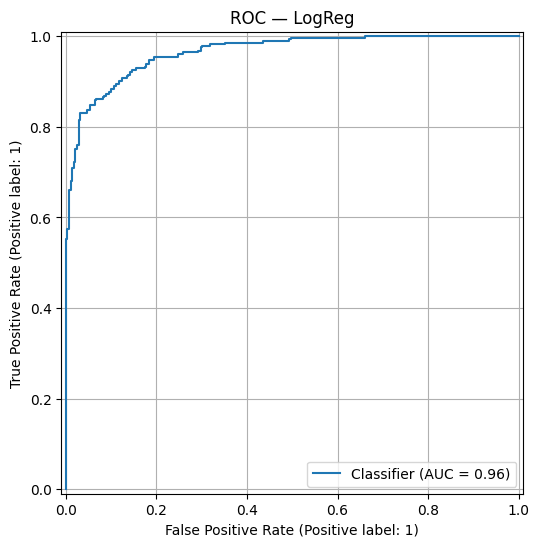

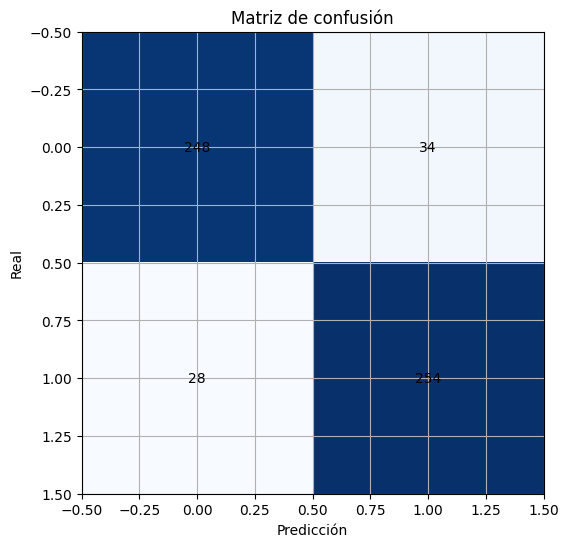

In [47]:
# Selección simple por AUC
models = {
    "Dummy": (None, y_pred_d, y_proba_d),
    "LogReg": (logit, y_pred_l, y_proba_l),
    "RandomForest": (rf, y_pred_rf, y_proba_rf)
}
best_name = max(models.items(), key=lambda kv: roc_auc_score(y_test, kv[1][2]))[0]
best_model, best_pred, best_proba = models[best_name]

print(f"Modelo seleccionado: {best_name}")
RocCurveDisplay.from_predictions(y_test, best_proba)
plt.title(f"ROC — {best_name}")
plt.show()

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusión")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
plt.show()

## Importancia de variables
- Si el modelo ganador es RF → `feature_importances_`.
- Si es LogReg → magnitud de coeficientes.

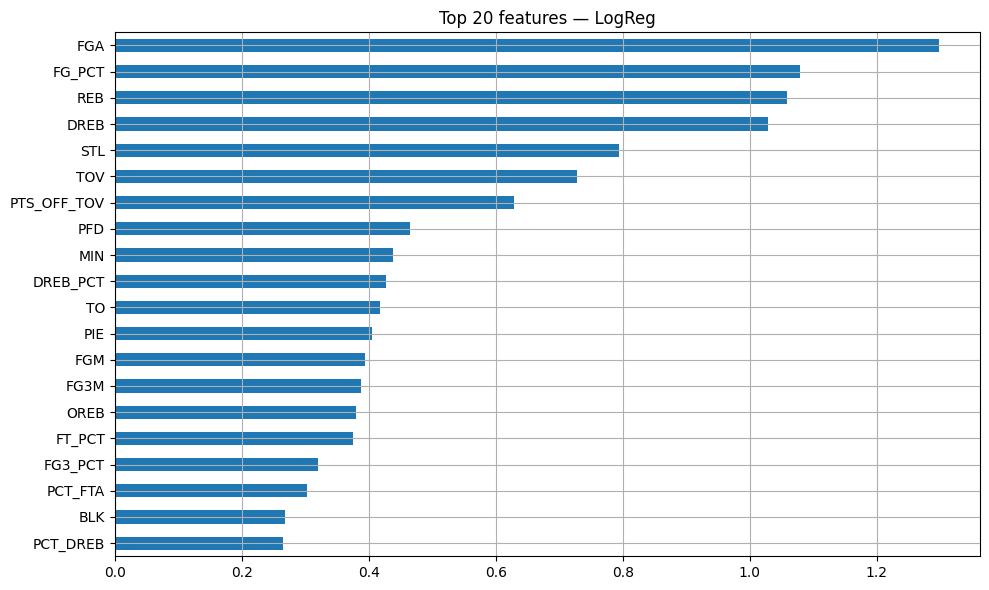

In [48]:
if best_name == "RandomForest":
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
else:
    # LogReg: coeficientes absolutos normalizados
    coefs = np.abs(best_model.named_steps["clf"].coef_[0])
    importances = pd.Series(coefs, index=X_train.columns).sort_values(ascending=False).head(20)

importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title(f"Top 20 features — {best_name}")
plt.tight_layout()
plt.show()

## Inference “bonita” para HOME vs AWAY
1. Calcula medias de los **últimos N** partidos para HOME y para AWAY (solo columnas `num_cols`).
2. Crea una fila “sintética” representando a HOME con sus medias y a la vez usando columnas `OPP_*` con las medias del rival cuando existan.
   - Ej.: `OPP_EFG_PCT` de HOME ← `EFG_PCT` del AWAY, etc.
3. Pasa esa fila al **modelo ganador** para obtener `P(win_HOME)`.

In [49]:
def prepare_team_features(team_name, last_n=20):
    """Prepara características para un equipo basado en sus últimos N partidos"""
    team_games = df_clean[df_clean['TEAM_NAME'] == team_name].sort_values('GAME_DATE')

    if len(team_games) < last_n:
        print(f"⚠️  {team_name} solo tiene {len(team_games)} partidos (se requieren {last_n})")
        # Usar todos los disponibles si no hay suficientes
        recent_games = team_games
    else:
        recent_games = team_games.tail(last_n)

    # Calcular medias de las características numéricas
    features = recent_games[num_cols].mean()

    return features

def predict_game_probability(home_team, away_team, last_n=20):
    """Predice la probabilidad de victoria del equipo local"""
    # Obtener características de ambos equipos
    home_features = prepare_team_features(home_team, last_n)
    away_features = prepare_team_features(away_team, last_n)

    # Combinar características (home primero, luego away)
    combined_features = []
    for col in X_train.columns:
        if col in home_features.index:
            combined_features.append(home_features[col])
        elif col in away_features.index:
            combined_features.append(away_features[col])
        else:
            # Si la característica no está disponible, usar la mediana del train
            combined_features.append(medians.get(col, 0))

    # Crear array para predicción
    X_new = np.array(combined_features).reshape(1, -1)

    # Asegurarse de que tenga las mismas dimensiones que X_train
    if X_new.shape[1] != X_train.shape[1]:
        print(f"⚠️  Dimensión mismatch: {X_new.shape[1]} vs {X_train.shape[1]}")
        # Rellenar o recortar si es necesario
        if X_new.shape[1] < X_train.shape[1]:
            padding = np.zeros((1, X_train.shape[1] - X_new.shape[1]))
            X_new = np.hstack([X_new, padding])
        else:
            X_new = X_new[:, :X_train.shape[1]]

    # Predecir
    if best_name == "RandomForest":
        proba = best_model.predict_proba(X_new)[0, 1]
    else:
        # Para Pipeline (LogReg)
        proba = best_model.predict_proba(X_new)[0, 1]

    return proba

# Probar la predicción
try:
    proba = predict_game_probability(HOME_TEAM, AWAY_TEAM, LAST_N)
    print(f"🏀 Probabilidad de victoria de {HOME_TEAM}: {proba:.1%}")
    print(f"🏀 Probabilidad de victoria de {AWAY_TEAM}: {1-proba:.1%}")

    # Verificar si la predicción es realista
    if proba > 0.9 or proba < 0.1:
        print("⚠️  ¡Cuidado! La predicción parece extrema")
    else:
        print("✅ La predicción parece razonable")

except Exception as e:
    print(f"❌ Error en la predicción: {e}")

🏀 Probabilidad de victoria de Oklahoma City Thunder: 94.3%
🏀 Probabilidad de victoria de Indiana Pacers: 5.7%
⚠️  ¡Cuidado! La predicción parece extrema


### Nota
- Esta aproximación usa medias recientes y rellena columnas `OPP_*` con las del rival si existen.
- Si quieres otra ventana (LAST_N), cambia el parámetro.
- Puedes inspeccionar `importances` para crear una selección de features personalizada.